# Denoising Diffusion Probabilistic Models (DDPM)

In [4]:
import os
import numpy as np
import pickle
import torch
import torchvision as tv
import torch.nn.functional as F
import torch.nn as nn

import tqdm as tqdm
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [5]:
import math
import torch.nn.functional as F

# ── Hiperparámetros DDPM ─────────────────────────────────────────────────
T          = 300   # Número de pasos de difusión (L en la presentación)
BETA_START = 1e-4  # β_1 (mínimo)
BETA_END   = 0.02  # β_T (máximo)

batch_size_ddpm = 128

In [6]:
# ── Schedule lineal de ruido ─────────────────────────────────────────────
#
# Sucesión β_1 < β_2 < ... < β_T  (monótona creciente, presentación §3.2)
# α_i  = √(1 - β_i²)  (aunque Ho et al. definen α_i = 1 - β_i)
# ᾱ_i  = ∏_{k=1}^{i} α_k        (producto acumulado)
#
# Forma directa del forward process (Lema presentación §3.2):
#   p_i(x_i|x_0) = N(ᾱ_i·x_0, (1 - ᾱ_i²)·I)
#
# Nota: aquí usamos la convención original de Ho et al. donde
#   β_i ∈ (0,1), α_i = 1 - β_i, ᾱ_i = ∏ α_k
# que es equivalente a la presentación pero más estándar en código.

betas      = torch.linspace(BETA_START, BETA_END, T, device=device)
alphas     = 1.0 - betas                               # α_i = 1 - β_i
alpha_bars = torch.cumprod(alphas, dim=0)              # ᾱ_i
alpha_bars_prev = F.pad(alpha_bars[:-1], (1, 0), value=1.0)  # ᾱ_{i-1}

# Términos reutilizados en forward y backward
sqrt_alpha_bars           = alpha_bars.sqrt()          # √ᾱ_i
sqrt_one_minus_alpha_bars = (1.0 - alpha_bars).sqrt()  # √(1 - ᾱ_i)
sqrt_recip_alphas         = alphas.rsqrt()             # 1/√α_i

# Varianza posterior σ²(i) = β_i·(1 - ᾱ_{i-1}) / (1 - ᾱ_i)  (presentación §3.5)
posterior_variance = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)

print(f'β_1 = {betas[0]:.5f}  |  β_T = {betas[-1]:.4f}')
print(f'ᾱ_1 = {alpha_bars[0]:.4f}  |  ᾱ_T ≈ {alpha_bars[-1]:.6f}  (≈0 confirma convergencia a N(0,I))')

β_1 = 0.00010  |  β_T = 0.0200
ᾱ_1 = 0.9999  |  ᾱ_T ≈ 0.048058  (≈0 confirma convergencia a N(0,I))


In [7]:
# ── Helper: extraer valor escalar indexado por t para un batch ───────────
#
# Dado un vector a de tamaño T y un batch de índices t (shape B),
# retorna a[t] con forma (B, 1, 1, 1) para broadcasting con imágenes.

def extract(a, t, x_shape):
    out = a.gather(-1, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

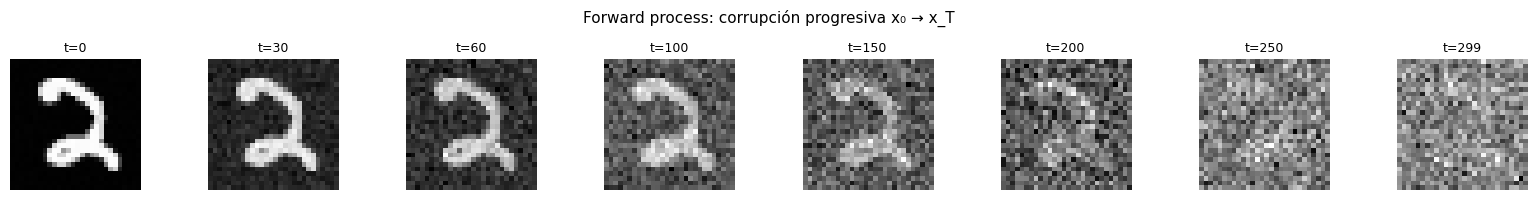

In [8]:
# ── Forward process q(x_t | x_0) ────────────────────────────────────────
#
# Forma directa (Lema §3.2 de la presentación):
#   x_t = √ᾱ_t · x_0  +  √(1 - ᾱ_t) · ε,   ε ~ N(0, I)
#
# Permite saltar directamente al paso t sin simular pasos intermedios.

def q_sample(x0, t, noise=None):
    """Corrompe x0 hasta el paso t usando la forma directa del forward process."""
    if noise is None:
        noise = torch.randn_like(x0)
    s_ab  = extract(sqrt_alpha_bars,           t, x0.shape)  # √ᾱ_t
    s_1ab = extract(sqrt_one_minus_alpha_bars, t, x0.shape)  # √(1-ᾱ_t)
    return s_ab * x0 + s_1ab * noise, noise


# Visualización del forward process en una sola imagen
with torch.no_grad():
    sample_img, _ = next(iter(DataLoader(
        tv.datasets.MNIST(root='./data', train=False, transform=transform_mnist),
        batch_size=1, shuffle=True
    )))
    sample_img = sample_img.to(device)
    steps_viz  = [0, 30, 60, 100, 150, 200, 250, 299]

    fig, axes = plt.subplots(1, len(steps_viz), figsize=(16, 2))
    for ax, step in zip(axes, steps_viz):
        t_viz = torch.tensor([step], device=device).long()
        x_t, _ = q_sample(sample_img, t_viz)
        ax.imshow(x_t.squeeze().cpu().numpy(), cmap='gray')
        ax.set_title(f't={step}', fontsize=9)
        ax.axis('off')
    plt.suptitle('Forward process: corrupción progresiva x₀ → x_T', fontsize=11)
    plt.tight_layout()
    plt.show()

In [9]:
# ── Arquitectura: U-Net para predicción de ruido ─────────────────────────
#
# La red ε_φ(x_t, t) estima el ruido ε que fue añadido a x_0.
# La condición de tiempo t se inyecta en cada bloque residual mediante
# Adaptive Group Normalization: la proyección del embedding de t proporciona
# un desplazamiento (bias) que modula los feature maps en cada paso.
#
# Arquitectura:
#   Encoder:     1×28×28  →  64×28×28  →  128×14×14  →  256×7×7
#   Bottleneck:  256×7×7  →  256×7×7
#   Decoder:     256×7×7  →  128×14×14 →  64×28×28   →  1×28×28
#   Skip connections entre encoder y decoder (U-Net estándar)

class SinusoidalTimeEmb(nn.Module):
    """
    Embedding sinusoidal del paso de tiempo t.
    Mismo principio que en Transformers (Vaswani et al. 2017).
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)


class ResBlock(nn.Module):
    """
    Bloque residual con inyección de embedding de tiempo.
    El embedding de t se proyecta a un sesgo que se suma
    a los feature maps tras la primera normalización.
    """
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        n_groups    = min(8, out_ch)
        self.norm1  = nn.GroupNorm(n_groups, out_ch)
        self.norm2  = nn.GroupNorm(n_groups, out_ch)
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(time_dim, out_ch)   # sesgo del tiempo
        self.act    = nn.SiLU()
        self.skip   = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.t_proj(t_emb)[:, :, None, None]  # inyección de t
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.skip(x)


class UNet(nn.Module):
    def __init__(self, time_dim=256):
        super().__init__()

        # Embedding de tiempo: sinusoidal → MLP
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmb(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # Encoder
        self.enc1  = ResBlock(1,   64,  time_dim)
        self.down1 = nn.Conv2d(64,  128, 4, stride=2, padding=1)  # 28→14
        self.enc2  = ResBlock(128, 128, time_dim)
        self.down2 = nn.Conv2d(128, 256, 4, stride=2, padding=1)  # 14→7
        self.enc3  = ResBlock(256, 256, time_dim)

        # Bottleneck
        self.mid = ResBlock(256, 256, time_dim)

        # Decoder (skip connections desde el encoder)
        self.up1  = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)  # 7→14
        self.dec1 = ResBlock(256, 128, time_dim)   # 256 = 128 (up) + 128 (skip enc2)
        self.up2  = nn.ConvTranspose2d(128,  64, 4, stride=2, padding=1)  # 14→28
        self.dec2 = ResBlock(128,  64, time_dim)   # 128 = 64  (up) +  64 (skip enc1)

        self.out  = nn.Conv2d(64, 1, 1)            # proyección final a canal de imagen

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        e1 = self.enc1(x, t_emb)                            # 64×28×28
        e2 = self.enc2(self.down1(e1), t_emb)               # 128×14×14
        e3 = self.enc3(self.down2(e2), t_emb)               # 256×7×7

        b  = self.mid(e3, t_emb)                            # 256×7×7

        d1 = self.dec1(torch.cat([self.up1(b),  e2], dim=1), t_emb)  # 128×14×14
        d2 = self.dec2(torch.cat([self.up2(d1), e1], dim=1), t_emb)  # 64×28×28

        return self.out(d2)                                  # 1×28×28


# Verificación de formas
with torch.no_grad():
    _m   = UNet().to(device)
    _x   = torch.randn(4, 1, 28, 28, device=device)
    _t   = torch.randint(0, T, (4,), device=device).long()
    _out = _m(_x, _t)
    print(f'U-Net output: {_out.shape}  (esperado: [4, 1, 28, 28]) ✓')
    print(f'Parámetros:   {sum(p.numel() for p in _m.parameters()):,}')
    del _m, _x, _t, _out

U-Net output: torch.Size([4, 1, 28, 28])  (esperado: [4, 1, 28, 28]) ✓
Parámetros:   4,964,481


In [10]:
# ── Pérdida simplificada L_simple ────────────────────────────────────────
#
# Derivada en la presentación §3.6:
#
#   L_simple(φ) = E_{i~U{1..T}, x0~p_data, ε~N(0,I)} [ ||ε - ε_φ(x_t, t)||² ]
#
#   donde x_t = √ᾱ_t·x_0 + √(1-ᾱ_t)·ε  (forma directa del forward process)
#
# Esta pérdida reemplaza la ponderada original del NELBO porque:
#   - Trata todos los pasos de forma uniforme (más estabilidad de gradientes)
#   - Es proporcional a ||μ(x_t,x_0,i) - μ_φ(x_t,i)||² con factor positivo

def p_losses(model, x0, t):
    noise        = torch.randn_like(x0)
    x_noisy, _   = q_sample(x0, t, noise)
    pred_noise   = model(x_noisy, t)
    return F.mse_loss(pred_noise, noise)

In [11]:
# ── Entrenamiento ─────────────────────────────────────────────────────────

ddpm_model = UNet().to(device)
ddpm_opt   = optim.Adam(ddpm_model.parameters(), lr=2e-4)

# DataLoader con batch más grande para el DDPM
train_loader_ddpm = DataLoader(
    tv.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist),
    batch_size=batch_size_ddpm, shuffle=True, num_workers=2, pin_memory=True
)

num_epochs_ddpm = 30
ddpm_model.train()
print(f'Entrenando DDPM por {num_epochs_ddpm} epochs  |  T={T}  |  {device}')
print(f'Parámetros: {sum(p.numel() for p in ddpm_model.parameters()):,}\n')

for epoch in range(num_epochs_ddpm):
    epoch_loss = 0.0
    for images, _ in train_loader_ddpm:
        images = images.to(device)
        # Muestrear t ~ U{1,...,T} para cada imagen del batch
        t = torch.randint(0, T, (images.shape[0],), device=device).long()

        ddpm_opt.zero_grad()
        loss = p_losses(ddpm_model, images, t)
        loss.backward()
        # Clip de gradientes para estabilidad
        torch.nn.utils.clip_grad_norm_(ddpm_model.parameters(), 1.0)
        ddpm_opt.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(train_loader_ddpm)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:>2}/{num_epochs_ddpm}]  L_simple: {avg:.5f}')

print('\nEntrenamiento DDPM completado ✓')
torch.save(ddpm_model.state_dict(), 'ddpm_mnist.pth')

Entrenando DDPM por 30 epochs  |  T=300  |  cuda:0
Parámetros: 4,964,481

Epoch [ 1/30]  L_simple: 0.10214
Epoch [ 5/30]  L_simple: 0.05523
Epoch [10/30]  L_simple: 0.05229
Epoch [15/30]  L_simple: 0.05046
Epoch [20/30]  L_simple: 0.04986
Epoch [25/30]  L_simple: 0.04917
Epoch [30/30]  L_simple: 0.04881

Entrenamiento DDPM completado ✓


In [13]:
# ── Backward process: muestreo p_φ(x_{t-1} | x_t) ──────────────────────
#
# Regla de actualización (presentación §3.6):
#
#   x_{t-1} = (1/√α_t) · (x_t - β_t/√(1-ᾱ_t) · ε_φ(x_t, t))  +  σ(t)·ε
#
# Donde:
#   - El primer término es μ_φ(x_t, t): media del paso inverso estimada
#   - σ²(t) = β_t·(1 - ᾱ_{t-1}) / (1 - ᾱ_t): varianza posterior
#   - ε ~ N(0,I): ruido añadido en cada paso (excepto t=0)

@torch.no_grad()
def p_sample_step(model, x, t_idx):
    """Un paso del proceso inverso: p_φ(x_{t-1} | x_t)."""
    t = torch.full((x.shape[0],), t_idx, device=device, dtype=torch.long)

    betas_t       = extract(betas,                      t, x.shape)
    sqrt_1ab_t    = extract(sqrt_one_minus_alpha_bars,  t, x.shape)
    sqrt_rec_a_t  = extract(sqrt_recip_alphas,          t, x.shape)

    pred_noise = model(x, t)

    # μ_φ(x_t, t) — media del backward process
    mean = sqrt_rec_a_t * (x - betas_t * pred_noise / sqrt_1ab_t)

    if t_idx == 0:
        return mean  # último paso: sin ruido adicional

    post_var = extract(posterior_variance, t, x.shape)
    return mean + torch.sqrt(post_var) * torch.randn_like(x)


@torch.no_grad()
def generate(model, n_samples=16):
    """
    Muestreo completo del backward process.
    Comienza con x_T ~ N(0,I) y aplica T pasos inversos hasta x_0.
    """
    model.eval()
    x = torch.randn(n_samples, 1, 28, 28, device=device)  # x_T ~ p_prior
    for t_idx in reversed(range(T)):                       # t = T-1, ..., 0
        x = p_sample_step(model, x, t_idx)
    return x.cpu()

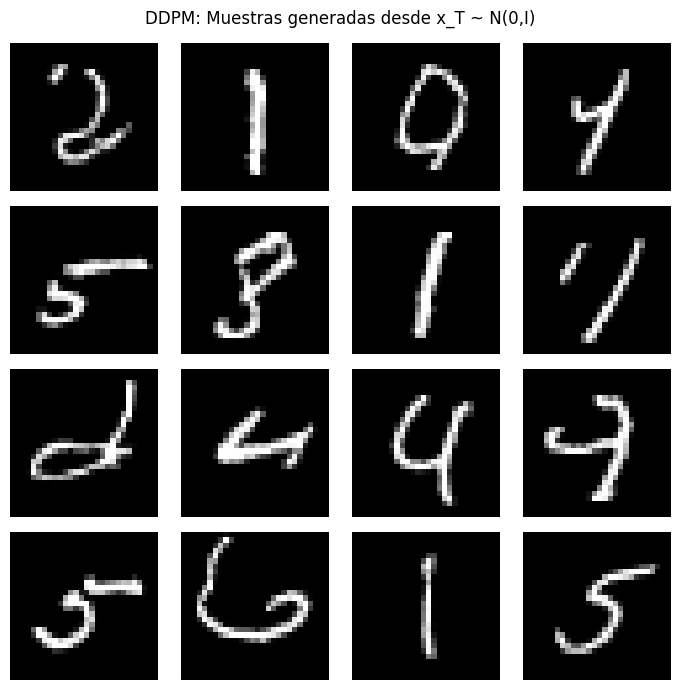

In [34]:
# ── Generación de muestras ───────────────────────────────────────────────

ddpm_model = UNet().to(device)
ddpm_model.load_state_dict(torch.load('ddpm_mnist.pth', map_location=device))

samples       = generate(ddpm_model, n_samples=16)
samples_denorm = denormalize_mnist(samples.to(device)).cpu()

fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples_denorm[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('DDPM: Muestras generadas desde x_T ~ N(0,I)', fontsize=12)
plt.tight_layout()
plt.show()

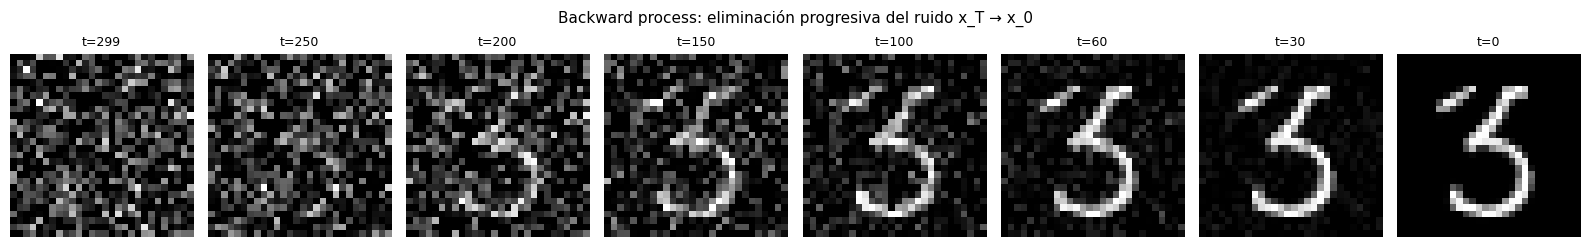

In [47]:
# ── Visualización del backward process ───────────────────────────────────
# Muestra cómo el modelo elimina el ruido paso a paso desde x_T hasta x_0

@torch.no_grad()
def generate_with_trajectory(model, steps_to_save):
    """Igual que generate() pero guarda x_t en los pasos indicados."""
    model.eval()
    x = torch.randn(1, 1, 28, 28, device=device)
    trajectory = {}
    for t_idx in reversed(range(T)):
        x = p_sample_step(model, x, t_idx)
        if t_idx in steps_to_save:
            trajectory[t_idx] = x.clone().cpu()
    return trajectory

steps_viz  = [299, 250, 200, 150, 100, 60, 30, 0]
trajectory = generate_with_trajectory(ddpm_model, set(steps_viz))

fig, axes = plt.subplots(1, len(steps_viz), figsize=(16, 2.5))
for ax, step in zip(axes, steps_viz):
    img = denormalize_mnist(trajectory[step].to(device)).cpu()
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f't={step}', fontsize=9)
    ax.axis('off')
plt.suptitle('Backward process: eliminación progresiva del ruido x_T → x_0', fontsize=11)
plt.tight_layout()
plt.show()